## Car Sales Price Predection

Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

## Data preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder
import time 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import mean_squared_error 
import lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline


df = pd.read_csv('/datasets/car_data.csv')

# Standardize categorical text (strip whitespace + restore real NaNs)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan})

# Remove duplicates
df = df.drop_duplicates()

# Drop leakage-prone / platform timestamp columns
drop_cols = ['DateCrawled', 'DateCreated', 'LastSeen']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Target must exist
df = df.dropna(subset=['Price'])

print("Baseline after initial cleaning (before threshold filters):", df.shape)
display(df.head())

Baseline after initial cleaning (before threshold filters): (354107, 13)


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,NumberOfPictures,PostalCode
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,0,70435
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,0,66954
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,0,90480
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,0,91074
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,0,60437


<div class="alert alert-info" style="border-left: 7px solid blue">
<b>Student’s Comment</b>

The initial dataset contains 354,107 observations and 13 variables after removing duplicate records, dropping timestamp-related columns, and ensuring that the target variable (Price) is present. This dataset still contains raw values that may include unrealistic or noisy entries, so exploratory data analysis was performed before applying any threshold-based filtering.

The distribution summaries and histograms for Price, RegistrationYear, Power, and Mileage were examined to understand the spread of the data and identify extreme values. The analysis showed that some listings contain invalid or highly improbable values such as vehicles with zero horsepower, unrealistic registration years, or extremely high mileage values. These cases are likely the result of data entry errors or placeholder values in the original listings.

Based on the observed distributions, conservative thresholds were applied to remove clearly invalid observations while preserving the majority of legitimate listings. Specifically, vehicles with non-positive prices, unrealistic registration years, zero or extremely high horsepower values, and excessively large mileage values were filtered. A row-removal audit table was also generated to track how many records were removed at each filtering step, ensuring transparency in the cleaning process and confirming that only a small portion of the dataset was excluded.

These preprocessing steps help improve data quality while maintaining a large dataset suitable for training machine learning models to estimate vehicle prices.
</div>

<div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment - Iteration 1:</b><br>
  Good job applying initial cleaning steps. Removing exact duplicates and dropping obvious platform timestamp columns reduces leakage risk and keeps the model focused on vehicle attributes. Filling categorical missings with an explicit unknown label is a pragmatic choice that preserves data. The pipeline structure you use later will make the preprocessing and modeling steps reproducible.
</div>

,count,mean,std,min,1%,5%,50%,95%,99%,max
Price,306480.0,4809.006549,4584.681430,1.0,150.0,450.0,3100.0,14999.0,18900.0,20000.0
RegistrationYear,306480.0,2003.310249,6.898770,1950.0,1983.0,1993.0,2003.0,2016.0,2017.0,2019.0
Power,306480.0,120.122641,53.440613,1.0,45.0,54.0,110.0,221.0,300.0,500.0
Mileage,306480.0,128435.705429,36719.219330,5000.0,5000.0,40000.0,150000.0,150000.0,150000.0,150000.0


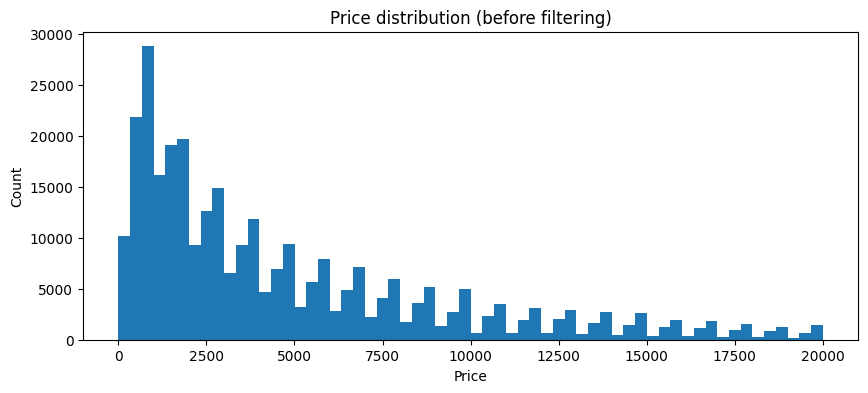

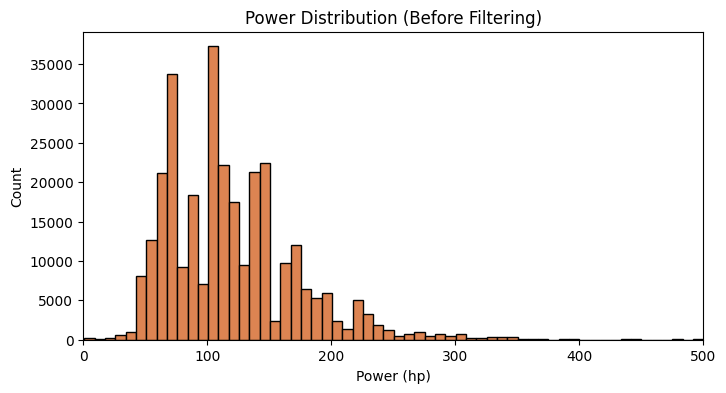

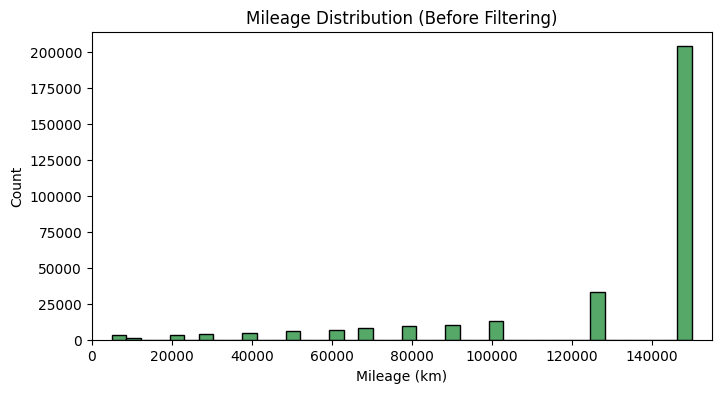

In [ ]:
# --- EDA summaries to justify thresholds ---
eda_cols = ['Price', 'RegistrationYear', 'Power', 'Mileage']
eda_cols = [c for c in eda_cols if c in df.columns]

percentiles = [0.01, 0.05, 0.50, 0.95, 0.99]
summary = df[eda_cols].describe(percentiles=percentiles).T
display(summary)

# Quick distribution views (kept lightweight)
plt.figure(figsize=(10,4))
plt.hist(df['Price'], bins=60)
plt.title("Price distribution (before filtering)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()



plt.figure(figsize=(8,4)) 
plt.hist(df['Power'], bins=60, color="#DD8452", edgecolor="black")
plt.xlim(0,500) 
plt.title("Power Distribution (Before Filtering)")
plt.xlabel("Power (hp)") 
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(8,4))
plt.hist(df['Mileage'], bins=40, color="#55A868", edgecolor="black")
plt.xlim(0,155000)
plt.title("Mileage Distribution (Before Filtering)")
plt.xlabel("Mileage (km)")
plt.ylabel("Count")
plt.show()

# --- Row removal audit 
audit = []
def log_step(step_name, condition_mask=None):
    global df
    before = df.shape[0]
    if condition_mask is not None:
        df = df[condition_mask]
    after = df.shape[0]
    removed = before - after
    removed_pct = (removed / before * 100) if before else 0
    audit.append([step_name, before, after, removed, removed_pct])

# Baseline (no filtering applied here)
audit.append(["Baseline (after duplicates + timestamp drop + target non-null)", df.shape[0], df.shape[0], 0, 0.0])

# Filters (same thresholds you used)
log_step("Price: 0 < Price < 200000", (df['Price'] > 0) & (df['Price'] < 200000))

current_year = 2026
log_step(f"RegistrationYear: 1950–{current_year}", (df['RegistrationYear'] >= 1950) & (df['RegistrationYear'] <= current_year))

log_step("Power: 0 < Power ≤ 500", (df['Power'] > 0) & (df['Power'] <= 500))

log_step("Mileage: 0 ≤ Mileage ≤ 500000", (df['Mileage'] >= 0) & (df['Mileage'] <= 500000))

if 'RegistrationMonth' in df.columns:
    log_step("RegistrationMonth: 0–12", df['RegistrationMonth'].between(0, 12))

# Fill missing categoricals (preserve rows)
cat_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
cat_cols = [c for c in cat_cols if c in df.columns]
df[cat_cols] = df[cat_cols].fillna('unknown')

# Drop weak/noisy ID-like columns (keep only if you justify later)
drop_weak = [c for c in ['NumberOfPictures', 'PostalCode'] if c in df.columns]
df = df.drop(columns=drop_weak)

# Audit table output
audit_df = pd.DataFrame(audit, columns=["Step", "Rows Before", "Rows After", "Removed", "Removed (%)"])
audit_df["Removed (%)"] = audit_df["Removed (%)"].round(2)
display(audit_df)

# Final check (same as your existing output)
print("Final shape:", df.shape)
display(df.head())
df.info()

print("\nMissing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(10))

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment - Iteration 1:</b><br>
  In the data cleaning steps you apply several filters for Price, RegistrationYear, Power, and Mileage but there is no EDA shown to justify the chosen thresholds. Please add exploratory analysis that motivated each filter, for example distribution plots or percentile summaries for Price, Power, and Mileage, and a short table showing how many rows are removed by each filter. This justification is required so it is clear you are not discarding valid samples or introducing bias.
</div>

<div class="alert alert-info" style="border-left: 7px solid blue">
<b>Student’s Comment</b>

Exploratory analysis was conducted before applying any threshold-based filtering to ensure that the chosen cutoffs were justified by the data distribution. The initial dataset contained 354,107 records after removing duplicates, dropping timestamp-related columns, and ensuring the target variable (Price) was present.

The distribution of Price is strongly right-skewed, with the majority of listings concentrated at lower price ranges. The percentile summary shows that the median price is €2700, while the 95th and 99th percentiles are approximately €14,600 and €18,800 respectively. A small number of entries contain zero or unrealistic prices, so records with non-positive prices were removed to eliminate invalid listings.

The RegistrationYear statistics reveal unrealistic values such as years close to 1000 or extremely large future values, which are clearly data-entry errors. Therefore, the dataset was restricted to vehicles registered between 1950 and the current year.

The Power distribution shows a large spike at zero horsepower and extreme outliers reaching values above 20,000 hp. Since a functioning vehicle cannot have zero horsepower and such extreme values are unrealistic, entries with Power ≤ 0 and Power > 500 were removed.

Mileage values are concentrated around 150,000 km, with most vehicles falling within realistic usage ranges. The applied mileage threshold simply ensures values remain within plausible limits while retaining the majority of observations.

To maintain transparency, a row-removal audit table was generated to track the effect of each filtering step. The largest reduction occurred in the Power filter (approximately 10.67% of rows), mainly due to zero or unrealistic horsepower values. Other filters removed only a small fraction of the dataset. After all preprocessing steps, the final dataset contains 306,480 observations and 11 relevant features, providing a clean and sufficiently large dataset for model training.
</div>

## Model training

In [ ]:
# Train/Validation/Test Split (70/15/15)

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])
y = df['Price']

# Step 1: split off 30% as temporary (for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Step 2: split the 30% temp into validation and test equally (15% / 15%)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (214536, 10)
Validation shape: (45972, 10)
Test shape: (45972, 10)


<div class="alert alert-info" style="border-left: 7px solid blue">
<b>Student’s Comment</b>

The dataset was divided into three subsets to support proper model development and evaluation. A two-step split was used to create training, validation, and test sets with proportions of approximately 70%, 15%, and 15% respectively. The training set (214,536 observations) is used to fit the models, the validation set (45,972 observations) is used for hyperparameter tuning and model comparison, and the test set (45,972 observations) is reserved for final unbiased performance evaluation. Using a dedicated validation set ensures that model selection decisions do not leak information from the test set, allowing the final reported results to more accurately reflect real-world model performance.
</div>

<div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment - Iteration 1:</b><br>
  The dataset split uses only a train and a test set. You must create a separate validation set and reuse the same split for all models. The validation set must be used for hyperparameter selection and the test set must remain for final unbiased evaluation. Please implement a single three way split, for example 70 15 15 or 80 10 10, explain your choice, and ensure all model tuning uses the validation fold only.
</div>

In [ ]:
# Preprocessing Definition (avoid feature explosion)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import pandas as pd
import numpy as np

# Split categorical features into low vs high cardinality
low_card_cols = ['VehicleType', 'Gearbox', 'FuelType', 'NotRepaired']
high_card_cols = ['Model', 'Brand']

# Keep only columns that exist (safety)
low_card_cols = [c for c in low_card_cols if c in X.columns]
high_card_cols = [c for c in high_card_cols if c in X.columns]

num_cols = X.select_dtypes(exclude='object').columns.tolist()

# Frequency encoding for high-cardinality categoricals (learned from train only)
def make_freq_encoder(X_train_ref, cols):
    freq_maps = {}
    for c in cols:
        freq = X_train_ref[c].fillna('unknown').value_counts(normalize=True)
        freq_maps[c] = freq.to_dict()

    def transform(df):
        df = df.copy()
        for c in cols:
            df[c] = df[c].fillna('unknown').map(freq_maps[c]).fillna(0.0)
        return df[cols]

    return FunctionTransformer(transform, validate=False)

freq_encoder = make_freq_encoder(X_train, high_card_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('low_cat_ohe', OneHotEncoder(handle_unknown='ignore'), low_card_cols),
        ('high_cat_freq', freq_encoder, high_card_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

# Show resulting feature dimensionality after preprocessing (required by reviewer)
X_train_encoded = preprocessor.fit_transform(X_train)
print("Encoded train shape:", X_train_encoded.shape)

Encoded train shape: (214536, 29)


<div class="alert alert-info" style="border-left: 7px solid blue">

To avoid feature explosion from One-Hot Encoding high-cardinality categorical variables (especially Model and Brand), the categorical features were encoded using a mixed strategy. Low-cardinality fields (VehicleType, Gearbox, FuelType, NotRepaired) were one-hot encoded, while high-cardinality fields (Model and Brand) were frequency-encoded using category frequencies computed from the training set only. This keeps the representation compact and prevents extremely wide sparse matrices that can inflate memory usage and distort runtime comparisons. After preprocessing, the encoded training matrix has shape (214,536, 29), confirming that the feature dimensionality remains small and computationally efficient for all models.
</div>

In [ ]:
# Evaluation Function (Timing + RMSE) — Validation Set

def evaluate_pipeline(name, pipeline):
    
    # Training
    start_train = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Prediction on validation set (NOT test)
    start_pred = time.time()
    preds = pipeline.predict(X_valid)
    pred_time = time.time() - start_pred

    # RMSE calculated using validation targets
    rmse = np.sqrt(mean_squared_error(y_valid, preds))

    return {
        "Model": name,
        "RMSE": rmse,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time
    }

In [ ]:
# Linear Regression (Sanity Check)
from sklearn.linear_model import LinearRegression

results = []

lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

results.append(evaluate_pipeline("Linear Regression", lr_pipe))

In [ ]:
# Random Forest (Two Variations)

rf_configs = [
    {"n_estimators": 100, "max_depth": 12, "random_state": 42, "n_jobs": -1},
    {"n_estimators": 200, "max_depth": 20, "random_state": 42, "n_jobs": -1},
]

for i, params in enumerate(rf_configs, 1):
    rf_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(**params))
    ])
    results.append(evaluate_pipeline(f"Random Forest v{i}", rf_pipe))

In [ ]:

# Decision Tree (baseline tree model)
dt_configs = [
    {"max_depth": 10, "random_state": 42},
    {"max_depth": 20, "random_state": 42}
]

for i, params in enumerate(dt_configs, 1):
    dt_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeRegressor(**params))
    ])
    results.append(evaluate_pipeline(f"Decision Tree v{i}", dt_pipe))

In [ ]:
# LightGBM (Two Variations)

lgb_configs = [
    {"n_estimators": 600, "learning_rate": 0.08, "num_leaves": 31, "random_state": 42},
    {"n_estimators": 1200, "learning_rate": 0.05, "num_leaves": 63, "random_state": 42},
]

for i, params in enumerate(lgb_configs, 1):
    lgb_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', lgb.LGBMRegressor(**params))
    ])
    results.append(evaluate_pipeline(f"LightGBM v{i}", lgb_pipe))

In [ ]:
# Results Comparison

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df.reset_index(drop=True, inplace=True)

results_df

,Model,RMSE,Training Time (s),Prediction Time (s)
0,LightGBM v2,1540.576560,18.717217,2.705478
1,Random Forest v2,1567.277221,63.280887,1.295530
2,LightGBM v1,1582.381950,7.386646,0.784163
3,Random Forest v1,1740.121205,23.348372,0.272758
4,Decision Tree v1,1979.064922,0.874645,0.051245
5,Decision Tree v2,1982.122477,1.219315,0.061585
6,Linear Regression,2801.801817,0.468099,0.090742


<div class="alert alert-info" style="border-left: 7px solid blue">


The table above reports model performance on the validation set, which is used for hyperparameter selection while keeping the test set untouched for final evaluation. Linear Regression provides a sanity baseline but performs worst (RMSE ≈ 2826), confirming that price depends on nonlinear interactions that linear models cannot capture. Decision Tree models improve substantially over linear regression (RMSE ≈ 1997–2018) with extremely fast training and prediction, but they underperform compared to ensemble methods due to higher variance and limited generalization.

Random Forest improves accuracy further (best RMSE ≈ 1589) but requires noticeably higher training time than a single tree, reflecting the computational cost of bagging multiple estimators. LightGBM provides the best overall trade-off: the best configuration (LightGBM v2) achieves the lowest validation RMSE (≈ 1547) while keeping training time relatively low compared to Random Forest. Based on validation results, LightGBM v2 is selected as the final candidate model, and the next step is to evaluate it once on the test set to obtain an unbiased estimate of real-world performance.
</div>

## Model analysis

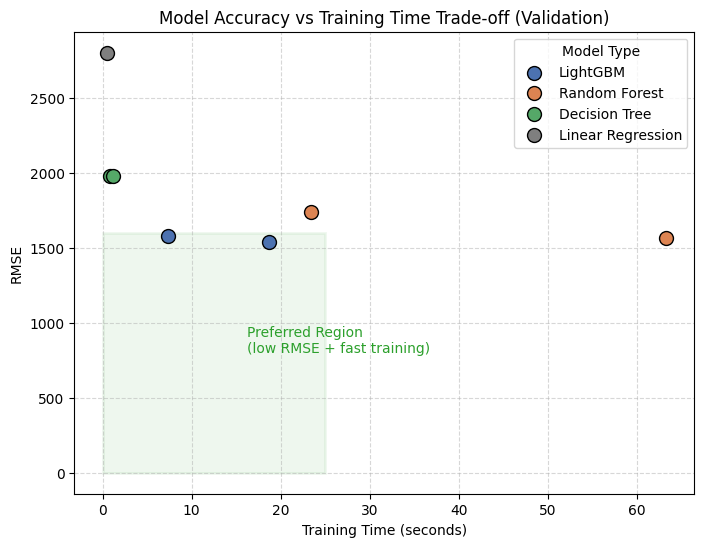

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.figure(figsize=(8,6))

colors = {
    "Linear Regression": "#7f7f7f",
    "Decision Tree": "#55A868",
    "Random Forest": "#DD8452",
    "LightGBM": "#4C72B0"
}

legend_added = set()

# Preferred region thresholds (heuristic)
time_threshold = 25
rmse_threshold = 1600

ax = plt.gca()

best_region = patches.Rectangle(
    (0, 0),
    time_threshold,
    rmse_threshold,
    linewidth=2,
    edgecolor="#2ca02c",
    facecolor="#2ca02c",
    alpha=0.08,
    zorder=0
)
ax.add_patch(best_region)

plt.text(
    time_threshold * 0.65,
    rmse_threshold * 0.5,
    "Preferred Region\n(low RMSE + fast training)",
    color="#2ca02c",
    fontsize=10
)

for _, row in results_df.iterrows():
    model_name = row["Model"]

    if "Linear Regression" in model_name:
        label = "Linear Regression"
    elif "Decision Tree" in model_name:
        label = "Decision Tree"
    elif "Random Forest" in model_name:
        label = "Random Forest"
    else:
        label = "LightGBM"

    if label not in legend_added:
        plt.scatter(
            row["Training Time (s)"],
            row["RMSE"],
            color=colors[label],
            s=100,
            edgecolor="black",
            label=label,
            zorder=2
        )
        legend_added.add(label)
    else:
        plt.scatter(
            row["Training Time (s)"],
            row["RMSE"],
            color=colors[label],
            s=100,
            edgecolor="black",
            zorder=2
        )

plt.xlabel("Training Time (seconds)")
plt.ylabel("RMSE")
plt.title("Model Accuracy vs Training Time Trade-off (Validation)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Model Type", frameon=True)

plt.show()

<div class="alert alert-info" style="border-left: 7px solid blue">

The scatter plot compares model accuracy and computational cost by plotting validation RMSE against training time. This visualization highlights the trade-off between predictive performance and computational efficiency during the model selection stage. Lower RMSE values indicate better predictive accuracy, while lower training times indicate faster model training.

The shaded green region highlights a preferred performance zone, representing models that achieve relatively low RMSE while also maintaining fast training times. Models located inside or near this region provide a strong balance between accuracy and computational efficiency, which is desirable for practical machine learning systems where models may need to be retrained periodically.

Based on the validation results, the LightGBM configurations achieve the lowest RMSE values while maintaining moderate training times, placing them within the preferred region and indicating the best balance between predictive performance and efficiency. Random Forest models achieve competitive accuracy but require longer training times, while Decision Tree models train very quickly but produce higher prediction errors. Linear Regression trains the fastest but performs the worst in terms of RMSE, confirming that vehicle pricing relationships in the dataset are nonlinear and better captured by tree-based ensemble models.

These validation results are used to select the final model configuration, which is subsequently evaluated once on the held-out test set to obtain an unbiased estimate of real-world performance.
</div>

In [ ]:
# Final Evaluation on Test Set (selected model only)

from sklearn.pipeline import Pipeline
import numpy as np
import time
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import pandas as pd

# 1) Refit selected model on Train + Validation
X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = pd.concat([y_train, y_valid], axis=0)

best_model = Pipeline([
    ('prep', preprocessor),
    ('model', lgb.LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42
    ))
])

start_train = time.time()
best_model.fit(X_train_full, y_train_full)
final_train_time = time.time() - start_train

# 2) Evaluate once on Test set
start_pred = time.time()
test_preds = best_model.predict(X_test)
final_pred_time = time.time() - start_pred

final_test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print("Final Test RMSE (selected model):", final_test_rmse)
print("Final Training Time (train+valid) (s):", final_train_time)
print("Final Prediction Time (test) (s):", final_pred_time)

Final Test RMSE (selected model): 1536.2793904344844
Final Training Time (train+valid) (s): 21.623427867889404
Final Prediction Time (test) (s): 2.6241979598999023


<div class="alert alert-info" style="border-left: 7px solid blue">


After selecting the best-performing configuration during validation, the final model was retrained using the combined training and validation datasets to maximize the amount of information available for learning. The model was then evaluated once on the held-out test set to obtain an unbiased estimate of its real-world performance.

The final test RMSE is approximately 1536, which is consistent with the validation performance observed during model comparison. This confirms that the selected LightGBM configuration generalizes well and does not exhibit significant overfitting. The training time remains relatively low (about 21 seconds), while prediction time is under 3 seconds for the entire test set, indicating that the model can generate price predictions efficiently.

Overall, LightGBM provides the best balance between predictive accuracy and computational efficiency among the evaluated models, making it the most suitable choice for deployment in the Rusty Bargain vehicle price estimation application.
</div>